**Trabalho Final - Ana Carolyne Pereira**

Dataset Escolhido: Adult
Prever se a renda anual de um indivíduo excede US$ 50 mil/ano com base em dados do censo.

URL: https://archive.ics.uci.edu/dataset/2/adult

In [ ]:
import pandas as pd

colunas = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

df = pd.read_csv("adult.data", header=None, names=colunas, na_values=" ?", skipinitialspace=True)


print(f"Shape do dataset: {df.shape}")
df.head()

Shape do dataset: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
# Distribuição Categórica

import pandas as pd

# Selecionando apenas variáveis categóricas
df_cat = df.select_dtypes(exclude=["number"]).copy()

df_cat = df_cat.astype(str)

# Transformando em formato long
df_long = df_cat.melt(var_name="variable", value_name="value")

# Contando frequências
df_counts = df_long.groupby(["variable", "value"]).size().reset_index(name="n")

# Calculando proporções
df_counts["frac"] = df_counts["n"] / len(df)

# Ordenando por variável e frequência
df_counts = df_counts.sort_values(by=["variable", "n"], ascending=[True, False])

print("Distribuição das Variáveis Categóricas:")
print("="*50)
for var in df_counts['variable'].unique():
    print(f"\n{var.upper()}:")
    var_data = df_counts[df_counts['variable'] == var]
    for _, row in var_data.iterrows():
        print(f"  {row['value']}: {row['n']} ({row['frac']:.3f})")

Distribuição das Variáveis Categóricas:

EDUCATION:
  HS-grad: 10501 (0.323)
  Some-college: 7291 (0.224)
  Bachelors: 5355 (0.164)
  Masters: 1723 (0.053)
  Assoc-voc: 1382 (0.042)
  11th: 1175 (0.036)
  Assoc-acdm: 1067 (0.033)
  10th: 933 (0.029)
  7th-8th: 646 (0.020)
  Prof-school: 576 (0.018)
  9th: 514 (0.016)
  12th: 433 (0.013)
  Doctorate: 413 (0.013)
  5th-6th: 333 (0.010)
  1st-4th: 168 (0.005)
  Preschool: 51 (0.002)

INCOME:
  <=50K: 24720 (0.759)
  >50K: 7841 (0.241)

MARITAL-STATUS:
  Married-civ-spouse: 14976 (0.460)
  Never-married: 10683 (0.328)
  Divorced: 4443 (0.136)
  Separated: 1025 (0.031)
  Widowed: 993 (0.030)
  Married-spouse-absent: 418 (0.013)
  Married-AF-spouse: 23 (0.001)

NATIVE-COUNTRY:
  United-States: 29170 (0.896)
  Mexico: 643 (0.020)
  ?: 583 (0.018)
  Philippines: 198 (0.006)
  Germany: 137 (0.004)
  Canada: 121 (0.004)
  Puerto-Rico: 114 (0.004)
  El-Salvador: 106 (0.003)
  India: 100 (0.003)
  Cuba: 95 (0.003)
  England: 90 (0.003)
  Jamaica: 

In [ ]:
# Estatísticas Descritivas

import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Selecionando apenas variáveis numéricas
variaveis_numericas = df.select_dtypes(include=["number"]).copy()

# Calculando estatísticas descritivas
desc = variaveis_numericas.describe().T

desc = desc.rename(columns={
    "mean": "media",
    "std": "desvio_padrao",
    "min": "minimo",
    "25%": "q25",
    "50%": "mediana",
    "75%": "q75",
    "max": "maximo"
})

# Selecionando e ordenando colunas
desc = desc[["media", "desvio_padrao", "minimo", "q25", "mediana", "q75", "maximo"]]
desc = desc.round(2)

# Criando tabela interativa com Plotly
fig = go.Figure(data=[go.Table(
    header=dict(values=["Variável", "Média", "Desvio Padrão", "Mínimo", "25%", "Mediana", "75%", "Máximo"],
                fill_color="#002147", font=dict(color="white"), align="center"),
    cells=dict(values=[
        desc.index,
        desc["media"],
        desc["desvio_padrao"],
        desc["minimo"],
        desc["q25"],
        desc["mediana"],
        desc["q75"],
        desc["maximo"]
    ],
    fill_color='lightgrey',
    align='center'))
])

fig.update_layout(
    title="Estatísticas Descritivas - Dataset Adult",
    width=1000,
    height=400
)
fig.show()

In [ ]:
# Comparação da variável target - Boxplot das variáveis numéricas por Income

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Lista das variáveis numéricas
vars_numericas = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# Criando subplots
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=vars_numericas,
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

# Cores para cada categoria de income
cores = {'<=50K': '#1f77b4', '>50K': '#ff7f0e'}

for i, var in enumerate(vars_numericas):
    row = (i // 3) + 1
    col = (i % 3) + 1

    # Boxplot para cada categoria de income
    for income_cat in ['<=50K', '>50K']:
        data = df[df['income'] == income_cat][var]

        fig.add_trace(
            go.Box(
                y=data,
                name=income_cat,
                marker_color=cores[income_cat],
                showlegend=(i == 0)  # Mostrar legenda apenas no primeiro gráfico
            ),
            row=row, col=col
        )

fig.update_layout(
    title="Distribuição das Variáveis Numéricas por Categoria de Income",
    height=600,
    width=1200
)

fig.show()

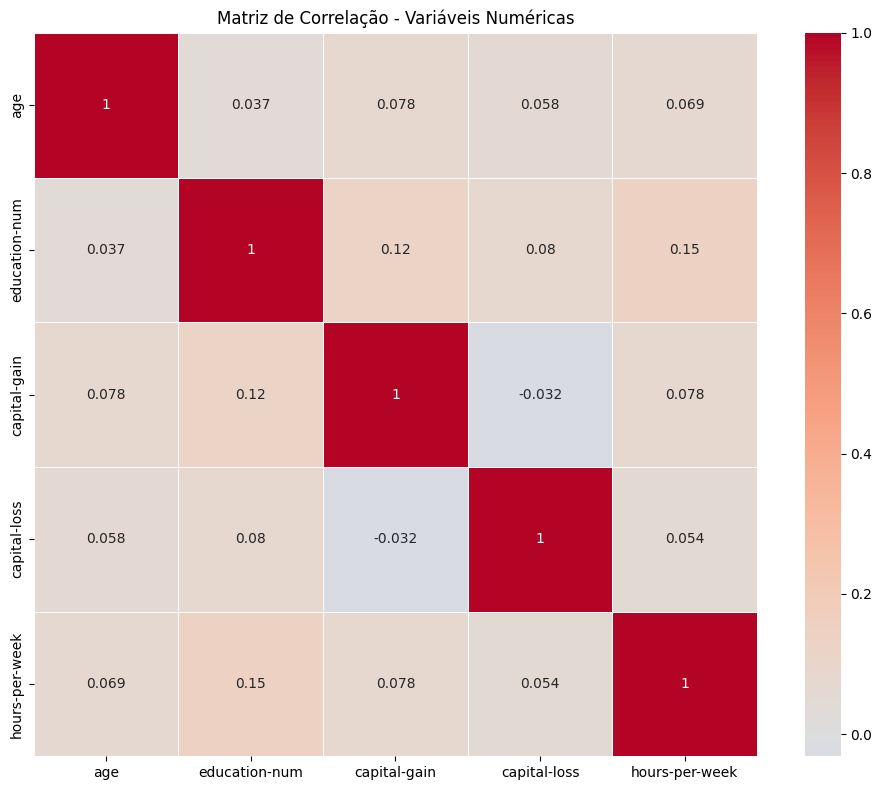

In [ ]:
# Matriz de correlação das variáveis numéricas
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

vars_numericas = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
correlation_matrix = df[vars_numericas].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.tight_layout()
plt.show()


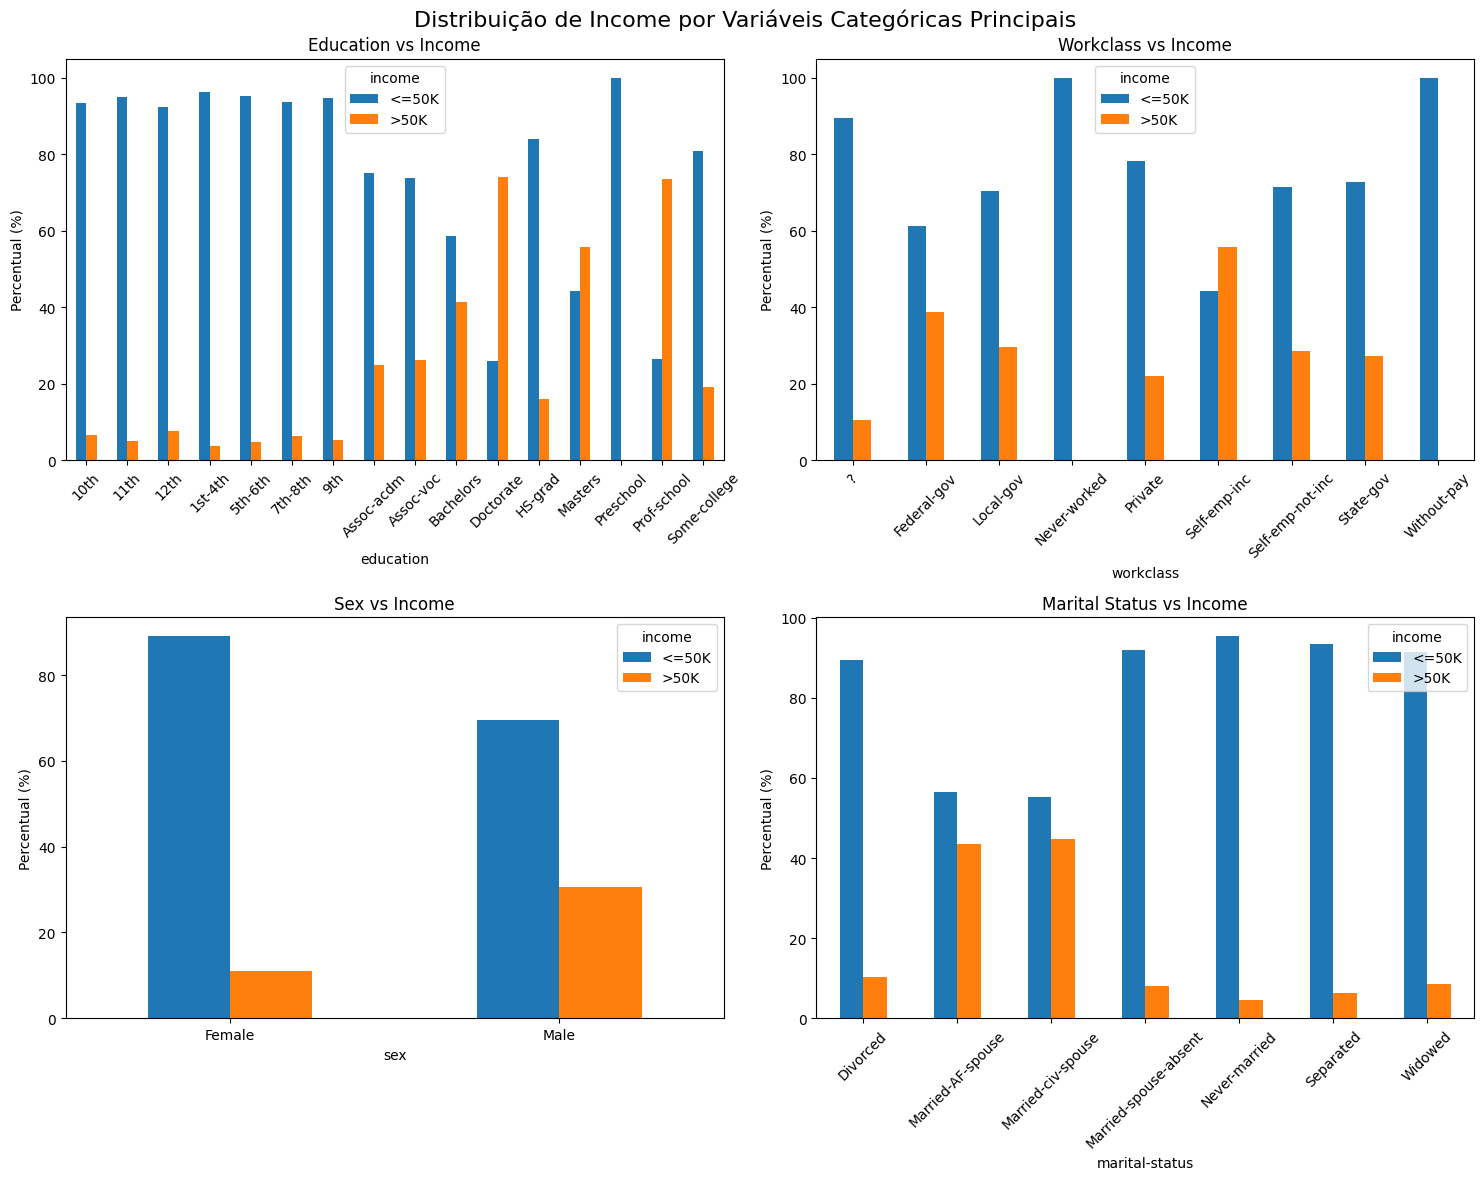

In [ ]:
# Análise das principais variáveis categóricas vs Income
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Distribuição de Income por Variáveis Categóricas Principais', fontsize=16)

# Education vs Income
education_income = pd.crosstab(df['education'], df['income'], normalize='index') * 100
education_income.plot(kind='bar', ax=axes[0,0], title='Education vs Income')
axes[0,0].set_ylabel('Percentual (%)')
axes[0,0].tick_params(axis='x', rotation=45)

# Workclass vs Income
workclass_income = pd.crosstab(df['workclass'], df['income'], normalize='index') * 100
workclass_income.plot(kind='bar', ax=axes[0,1], title='Workclass vs Income')
axes[0,1].set_ylabel('Percentual (%)')
axes[0,1].tick_params(axis='x', rotation=45)

# Sex vs Income
sex_income = pd.crosstab(df['sex'], df['income'], normalize='index') * 100
sex_income.plot(kind='bar', ax=axes[1,0], title='Sex vs Income')
axes[1,0].set_ylabel('Percentual (%)')
axes[1,0].tick_params(axis='x', rotation=0)

# Marital Status vs Income
marital_income = pd.crosstab(df['marital-status'], df['income'], normalize='index') * 100
marital_income.plot(kind='bar', ax=axes[1,1], title='Marital Status vs Income')
axes[1,1].set_ylabel('Percentual (%)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# KNN
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from scipy.stats import zscore

# Carregamento e preparação dos dados
colunas = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

df = pd.read_csv("adult.data", header=None, names=colunas, na_values=" ?", skipinitialspace=True)
df = df.dropna()

categorical_cols = ['workclass', 'education', 'marital-status', 'occupation',
                   'relationship', 'race', 'sex', 'native-country']

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

df['income'] = LabelEncoder().fit_transform(df['income'])

X = df.drop(columns=['income'])
y = df['income']

print("\n" + "="*50)
print("KNN - K-NEAREST NEIGHBORS")
print("="*50)

# Remoção de outliers
z_scores = np.abs(zscore(X.select_dtypes(include=[np.number])))
outlier_mask = (z_scores < 3).all(axis=1)
X_knn = X[outlier_mask]
y_knn = y[outlier_mask]

# Normalização
scaler = StandardScaler()
X_knn_scaled = scaler.fit_transform(X_knn)

# Seleção de Features
selector = SelectKBest(score_func=f_classif, k=10)
X_knn_selected = selector.fit_transform(X_knn_scaled, y_knn)

# PCA
pca = PCA(n_components=8)
X_knn_pca = pca.fit_transform(X_knn_selected)

print(f"Features após pré-processamento: {X_knn_pca.shape[1]}")
print(f"Variância explicada pelo PCA: {pca.explained_variance_ratio_.sum():.4f}")

# Divisão treino/teste
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn_pca, y_knn, test_size=0.2, random_state=42)

# Testando diferentes valores de k
for k_value in [3, 5, 7, 9, 11]:
    knn_model = KNeighborsClassifier(n_neighbors=k_value)
    cv_scores = cross_val_score(knn_model, X_train_knn, y_train_knn, cv=5)

    print(f"\nValor de k = {k_value}")
    for fold, acc in enumerate(cv_scores, start=1):
        print(f"Acurácia na fold {fold}: {acc:.4f}")
    print(f"Acurácia média na validação cruzada: {cv_scores.mean():.4f}")

# Modelo final com melhor k
best_knn = KNeighborsClassifier(n_neighbors=11)
start_time = time.time()
best_knn.fit(X_train_knn, y_train_knn)
knn_train_time = time.time() - start_time

start_time = time.time()
y_pred_knn = best_knn.predict(X_test_knn)
knn_pred_time = time.time() - start_time

# Calcular as métricas de precisão, revocação, F1-score e especificidade
precision_knn = precision_score(y_test_knn, y_pred_knn, pos_label=1)
recall_knn = recall_score(y_test_knn, y_pred_knn, pos_label=1)
f1_knn = f1_score(y_test_knn, y_pred_knn, pos_label=1)

# Calcular a especificidade manualmente
conf_matrix = confusion_matrix(y_test_knn, y_pred_knn)
specificity_knn = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])

print(f"\nRESULTADOS FINAIS KNN (k=11):")
print(f"Tempo de treinamento: {knn_train_time:.4f}s")
print(f"Tempo de predição: {knn_pred_time:.4f}s")
print("\nMétricas:")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-score: {f1_knn:.4f}")
print(f"Especificidade: {specificity_knn:.4f}")


KNN - K-NEAREST NEIGHBORS
Features após pré-processamento: 8
Variância explicada pelo PCA: 0.9020

Valor de k = 3
Acurácia na fold 1: 0.8231
Acurácia na fold 2: 0.8341
Acurácia na fold 3: 0.8331
Acurácia na fold 4: 0.8192
Acurácia na fold 5: 0.8290
Acurácia média na validação cruzada: 0.8277

Valor de k = 5
Acurácia na fold 1: 0.8288
Acurácia na fold 2: 0.8470
Acurácia na fold 3: 0.8427
Acurácia na fold 4: 0.8254
Acurácia na fold 5: 0.8397
Acurácia média na validação cruzada: 0.8367

Valor de k = 7
Acurácia na fold 1: 0.8341
Acurácia na fold 2: 0.8482
Acurácia na fold 3: 0.8459
Acurácia na fold 4: 0.8315
Acurácia na fold 5: 0.8427
Acurácia média na validação cruzada: 0.8405

Valor de k = 9
Acurácia na fold 1: 0.8407
Acurácia na fold 2: 0.8505
Acurácia na fold 3: 0.8466
Acurácia na fold 4: 0.8350
Acurácia na fold 5: 0.8429
Acurácia média na validação cruzada: 0.8431

Valor de k = 11
Acurácia na fold 1: 0.8445
Acurácia na fold 2: 0.8543
Acurácia na fold 3: 0.8484
Acurácia na fold 4: 0.8

In [ ]:
# NAIVE BAYES

import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from scipy.stats import zscore

# Carregamento e preparação dos dados
colunas = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

df = pd.read_csv("adult.data", header=None, names=colunas, na_values=" ?", skipinitialspace=True)
df = df.dropna()

categorical_cols = ['workclass', 'education', 'marital-status', 'occupation',
                   'relationship', 'race', 'sex', 'native-country']

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

df['income'] = LabelEncoder().fit_transform(df['income'])

X = df.drop(columns=['income'])
y = df['income']

print("\n" + "="*50)
print("NAIVE BAYES")
print("="*50)

# Remoção de outliers
z_scores = zscore(X.select_dtypes(include=[np.number]))
mask = (abs(z_scores) < 3).all(axis=1)
X_nb = X[mask]
y_nb = y[mask]

# Normalização
scaler_nb = StandardScaler()
X_nb_scaled = scaler_nb.fit_transform(X_nb)

# Seleção de features
selector_nb = SelectKBest(score_func=f_classif, k=12)
X_nb_selected = selector_nb.fit_transform(X_nb_scaled, y_nb)

print(f"Features selecionadas: {X_nb_selected.shape[1]}")

# Divisão treino/teste
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb_selected, y_nb, test_size=0.2, random_state=42)

# Naive Bayes com validação cruzada
nb_model = GaussianNB()
cv_scores_nb = cross_val_score(nb_model, X_train_nb, y_train_nb, cv=5)

print("Validação Cruzada:")
for fold, acc in enumerate(cv_scores_nb, start=1):
    print(f"Acurácia na fold {fold}: {acc:.4f}")
print(f"Acurácia média na validação cruzada: {cv_scores_nb.mean():.4f}")

# Treinamento e predição
start_time = time.time()
nb_model.fit(X_train_nb, y_train_nb)
nb_train_time = time.time() - start_time

start_time = time.time()
y_pred_nb = nb_model.predict(X_test_nb)
nb_pred_time = time.time() - start_time

# Calcular as métricas de precisão, revocação, F1-score e especificidade
precision_nb = precision_score(y_test_nb, y_pred_nb, pos_label=1)
recall_nb = recall_score(y_test_nb, y_pred_nb, pos_label=1)
f1_nb = f1_score(y_test_nb, y_pred_nb, pos_label=1)

# Calcular a especificidade manualmente
conf_matrix = confusion_matrix(y_test_nb, y_pred_nb)
specificity_nb = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])

print(f"\nRESULTADOS FINAIS NAIVE BAYES:")
print(f"Tempo de treinamento: {nb_train_time:.4f}s")
print(f"Tempo de predição: {nb_pred_time:.4f}s")
print("\nMétricas:")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall: {recall_nb:.4f}")
print(f"F1-score: {f1_nb:.4f}")
print(f"Especificidade: {specificity_nb:.4f}")


NAIVE BAYES
Features selecionadas: 12
Validação Cruzada:
Acurácia na fold 1: 0.8313
Acurácia na fold 2: 0.8252
Acurácia na fold 3: 0.8270
Acurácia na fold 4: 0.8252
Acurácia na fold 5: 0.8235
Acurácia média na validação cruzada: 0.8264

RESULTADOS FINAIS NAIVE BAYES:
Tempo de treinamento: 0.0076s
Tempo de predição: 0.0017s

Métricas:
Precision: 0.6287
Recall: 0.5586
F1-score: 0.5916
Especificidade: 0.9021


In [ ]:
# ÁRVORE DE DECISÃO

import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from scipy.stats import zscore

colunas = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

df = pd.read_csv("adult.data", header=None, names=colunas, na_values=" ?", skipinitialspace=True)
df = df.dropna()

categorical_cols = ['workclass', 'education', 'marital-status', 'occupation',
                   'relationship', 'race', 'sex', 'native-country']

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

df['income'] = LabelEncoder().fit_transform(df['income'])

X = df.drop(columns=['income'])
y = df['income']

print("\n" + "="*50)
print("ÁRVORE DE DECISÃO")
print("="*50)

# Remoção de outliers
z_scores = zscore(X.select_dtypes(include=[np.number]))
filtered_entries = (abs(z_scores) < 3).all(axis=1)
X_dt = X[filtered_entries]
y_dt = y[filtered_entries]

# Normalização
scaler_dt = StandardScaler()
X_dt_scaled = scaler_dt.fit_transform(X_dt)

# Seleção de features
selector_dt = SelectKBest(score_func=f_classif, k=15)
X_dt_selected = selector_dt.fit_transform(X_dt_scaled, y_dt)

print(f"Features selecionadas: {X_dt_selected.shape[1]}")

# Divisão treino/teste
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt_selected, y_dt, test_size=0.2, random_state=42)

# Testando diferentes parâmetros
params_to_test = [
    {'max_depth': 5, 'min_samples_split': 10},
    {'max_depth': 10, 'min_samples_split': 5},
    {'max_depth': 15, 'min_samples_split': 2},
    {'max_depth': None, 'min_samples_split': 5}
]

print("Testando diferentes parâmetros:")
for i, params in enumerate(params_to_test):
    dt_model = DecisionTreeClassifier(random_state=42, **params)
    cv_scores = cross_val_score(dt_model, X_train_dt, y_train_dt, cv=5)
    print(f"Parâmetros {i+1}: {params}")
    print(f"Acurácia média CV: {cv_scores.mean():.4f}")

# Modelo final
final_dt = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

start_time = time.time()
final_dt.fit(X_train_dt, y_train_dt)
dt_train_time = time.time() - start_time

start_time = time.time()
y_pred_dt = final_dt.predict(X_test_dt)
dt_pred_time = time.time() - start_time

# Validação cruzada final
cv_scores_dt = cross_val_score(final_dt, X_train_dt, y_train_dt, cv=5)
print(f"\nValidação Cruzada (modelo final):")
for fold, accuracy in enumerate(cv_scores_dt, start=1):
    print(f'Acurácia na fold {fold}: {accuracy:.4f}')
print(f'Acurácia média na validação cruzada: {cv_scores_dt.mean():.4f}')

# Calcular as métricas de precisão, revocação, F1-score e especificidade
precision_dt = precision_score(y_test_dt, y_pred_dt, pos_label=1)
recall_dt = recall_score(y_test_dt, y_pred_dt, pos_label=1)
f1_dt = f1_score(y_test_dt, y_pred_dt, pos_label=1)

# Calcular a especificidade manualmente
conf_matrix = confusion_matrix(y_test_dt, y_pred_dt)
specificity_dt = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])

print(f"\nRESULTADOS FINAIS ÁRVORE DE DECISÃO:")
print(f"Tempo de treinamento: {dt_train_time:.4f}s")
print(f"Tempo de predição: {dt_pred_time:.4f}s")
print("\nMétricas:")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print(f"Especificidade: {specificity_dt:.4f}")


ÁRVORE DE DECISÃO
Features selecionadas: 14
Testando diferentes parâmetros:


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning:

k=15 is greater than n_features=14. All the features will be returned.



Parâmetros 1: {'max_depth': 5, 'min_samples_split': 10}
Acurácia média CV: 0.8516
Parâmetros 2: {'max_depth': 10, 'min_samples_split': 5}
Acurácia média CV: 0.8494
Parâmetros 3: {'max_depth': 15, 'min_samples_split': 2}
Acurácia média CV: 0.8298
Parâmetros 4: {'max_depth': None, 'min_samples_split': 5}
Acurácia média CV: 0.8133

Validação Cruzada (modelo final):
Acurácia na fold 1: 0.8514
Acurácia na fold 2: 0.8518
Acurácia na fold 3: 0.8587
Acurácia na fold 4: 0.8432
Acurácia na fold 5: 0.8527
Acurácia média na validação cruzada: 0.8516

RESULTADOS FINAIS ÁRVORE DE DECISÃO:
Tempo de treinamento: 0.0448s
Tempo de predição: 0.0010s

Métricas:
Precision: 0.7972
Recall: 0.4606
F1-score: 0.5838
Especificidade: 0.9652


In [ ]:
print("\n" + "="*70)
print("COMPARAÇÃO DE DESEMPENHO")
print("="*70)

# Dados da comparação
results = {
    'Algoritmo': ['KNN', 'Naive Bayes', 'Árvore de Decisão'],
    'Tempo_Treino': [knn_train_time, nb_train_time, dt_train_time],
    'Tempo_Pred': [knn_pred_time, nb_pred_time, dt_pred_time],
    'Precision': [precision_knn, precision_nb, precision_dt],
    'Recall': [recall_knn, recall_nb, recall_dt],
    'F1-Score': [f1_knn, f1_nb, f1_dt],
    'Especificidade': [specificity_knn, specificity_nb, specificity_dt]
}

comparison_df = pd.DataFrame(results)
print(comparison_df.round(4))

# Melhor modelo
best_f1_idx = comparison_df['F1-Score'].idxmax()
best_model = comparison_df.iloc[best_f1_idx]['Algoritmo']

print(f"\nMELHOR MODELO: {best_model}")
print(f"F1-Score: {comparison_df.iloc[best_f1_idx]['F1-Score']:.4f}")


COMPARAÇÃO DE DESEMPENHO
           Algoritmo  Tempo_Treino  Tempo_Pred  Precision  Recall  F1-Score  \
0                KNN        0.0268      0.4899     0.6873  0.5570    0.6153   
1        Naive Bayes        0.0076      0.0017     0.6287  0.5586    0.5916   
2  Árvore de Decisão        0.0448      0.0010     0.7972  0.4606    0.5838   

   Especificidade  
0          0.9248  
1          0.9021  
2          0.9652  

MELHOR MODELO: KNN
F1-Score: 0.6153
